In [1]:
# [코드 11-1] 데이터프레임 생성 (딕셔너리 방식)
import pandas as pd

data = {
    'name': ['김철수', '이영희', '박민수', '최지원'],
    'test':    [85, 92, 78, 88],
    'assign1': [90, 85, 80, 95],
    'assign2': [88, 90, 75, 92]
}
df = pd.DataFrame(data)
display(df)  # 또는 print(df)

,name,test,assign1,assign2
0,김철수,85,90,88
1,이영희,92,85,90
2,박민수,78,80,75
3,최지원,88,95,92


In [2]:
df['name'] #원하는 열만 보기

,name
0,김철수
1,이영희
2,박민수
3,최지원


In [3]:
df[['name', 'test']] #괄호 두개 쳐야함

,name,test
0,김철수,85
1,이영희,92
2,박민수,78
3,최지원,88


In [4]:
for idx, row in df.iterrows():
    print(idx, row['name'], row['test'])

0 김철수 85
1 이영희 92
2 박민수 78
3 최지원 88


In [9]:
# [코드 11-10] 열 간 연산
df['sum'] = df['test'] + df['assign1'] + df['assign2']
print(df['sum'])

0    263
1    267
2    233
3    275
Name: sum, dtype: int64


In [13]:
# [코드 11-11] 조건에 맞는 행 추출
df[df['sum'] >= 265]

,name,test,assign1,assign2,sum
1,이영희,92,85,90,267
3,최지원,88,95,92,275


In [26]:
# [코드 11-13] 열 이름 변경
df = df.rename(columns={'test': 'exam'})
print(df)

  name  exam  assign1  assign2  sum grade result
0  김철수    85       90       88  263     A   pass
1  이영희    92       85       90  267     A   pass
2  박민수    78       80       75  233     A   pass
3  최지원    88       95       92  275     A   pass


In [25]:
# [코드 11-14] 'sum' 열 기준 내림차순 정렬
sort_df = df.sort_values(by='sum', ascending=False)
print(sort_df)

  name  exam  assign1  assign2  sum grade result
3  최지원    88       95       92  275     A   pass
1  이영희    92       85       90  267     A   pass
0  김철수    85       90       88  263     A   pass
2  박민수    78       80       75  233     A   pass


In [30]:
# [코드 11-15] 조건에 따라 'grade' 열 생성 (다중 조건)
import numpy as np
df['grade'] = np.where(df['sum'] >= 265, 'A',
              np.where(df['sum'] >= 240, 'B', 'C'))
print(df)

  name  exam  assign1  assign2  sum grade result
0  김철수    85       90       88  263     B   pass
1  이영희    92       85       90  267     A   pass
2  박민수    78       80       75  233     C   pass
3  최지원    88       95       92  275     A   pass


In [41]:
# [코드 11-16] 합격/불합격 분류
df['result'] = np.where(df['sum'] >= 240, 'pass', 'fail')
print(df)

# [코드 11-17] 빈도수 확인
df['result'].value_counts()
# pass    3
# fail    1


  name  exam  assign1  assign2  sum grade result
0  김철수    85       90       88  263     B   pass
1  이영희    92       85       90  267     A   pass
2  박민수    78       80       75  233     C   fail
3  최지원    88       95       92  275     A   pass


,count
result,
pass,3
fail,1


In [42]:
# [코드 11-19] 열 삭제
df = df.drop(columns=['result'])
print(df)

  name  exam  assign1  assign2  sum grade
0  김철수    85       90       88  263     B
1  이영희    92       85       90  267     A
2  박민수    78       80       75  233     C
3  최지원    88       95       92  275     A


In [43]:
df.to_csv('exam_out.csv')

In [44]:
import pandas as pd
import numpy as np

data = {
    'name':   ['김철수', '이영희', np.nan, '최지원', '정민호'],
    'gender': ['M', 'F', 'F', np.nan, 'M'],
    'score':  [85, np.nan, 78, 92, np.nan]
}
df = pd.DataFrame(data)
display(df)

,name,gender,score
0,김철수,M,85.0
1,이영희,F,NaN
2,NaN,F,78.0
3,최지원,NaN,92.0
4,정민호,M,NaN


In [45]:
# [코드 11-23] 누락 여부 확인 (전체 표 반환)
df.isna()
# True/False로 채워진 같은 크기의 표

# 열별 누락 개수 (대규모 데이터에서 실용적)
df.isna().sum()
# name      1
# gender    1
# score     2

# 전체 누락 개수
df.isna().sum().sum()  # 4

np.int64(4)

In [46]:
# [코드 11-28] 모든 NaN을 0으로 대체
df1 = df.fillna(0)

# [코드 11-29] 열마다 다른 값으로 대체 (딕셔너리)
df2 = df.fillna({
    'gender': 'etc',   # 범주형 → 'etc'
    'score':  0        # 수치형 → 0
})

# [코드 11-30] 평균으로 대체 (수치형 권장)
df3 = df.fillna({'score': df['score'].mean()})

# [코드 11-31] 원본 반영
df.fillna({'score': df['score'].mean()}, inplace=True)

In [47]:
df1

,name,gender,score
0,김철수,M,85.0
1,이영희,F,0.0
2,0,F,78.0
3,최지원,0,92.0
4,정민호,M,0.0


In [48]:
df2

,name,gender,score
0,김철수,M,85.0
1,이영희,F,0.0
2,NaN,F,78.0
3,최지원,etc,92.0
4,정민호,M,0.0


In [49]:
df3

,name,gender,score
0,김철수,M,85.0
1,이영희,F,85.0
2,NaN,F,78.0
3,최지원,NaN,92.0
4,정민호,M,85.0


In [50]:
# [코드 11-32, 11-33, 11-34] 두 DF를 'name' 기준으로 결합
df1 = pd.DataFrame({
    'name':   ['김철수', '이영희', '박민수'],
    'gender': ['M', 'F', 'M'],
    'age':    [21, 22, 20]
})
df2 = pd.DataFrame({
    'name':       ['김철수', '이영희', '박민수'],
    'department': ['컴퓨터공학', '경영학', '토목공학']
})

df3 = pd.merge(df1, df2, on='name')
display(df3)

# [코드 11-35, 11-36] 또 다른 키로 추가 결합
df4 = pd.DataFrame({
    'department':       ['컴퓨터공학', '경영학', '토목공학'],
    'head of department': ['이정수', '김영규', '최희재']
})
df5 = pd.merge(df3, df4, on='department')

,name,gender,age,department
0,김철수,M,21,컴퓨터공학
1,이영희,F,22,경영학
2,박민수,M,20,토목공학


In [66]:
# [코드 11-40] CSV 파일 읽기
df = pd.read_csv('precipitation.csv')

# [코드 11-43] CSV 파일 저장
df.to_csv('precipitation_out.csv')

# [코드 11-44] 행 인덱스 번호 제외하고 저장 (실무 표준)
df.to_csv('precipitation_out.csv', index=False)

In [67]:
# [코드 11-49, 11-50] 한글 폰트 설치 (Colab 환경)
!apt-get update -qq
!apt-get install fonts-nanum -qq
!fc-cache -fv

import matplotlib.font_manager as fm
font10 = fm.FontProperties(
    fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    size=10
)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped dire

In [97]:
df = pd.read_csv('학급당학생수.csv', encoding='cp949')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   항목       14 non-null     object 
 1   시점       14 non-null     int64  
 2   서울특별시    14 non-null     float64
 3   제주특별자치도  14 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 580.0+ bytes


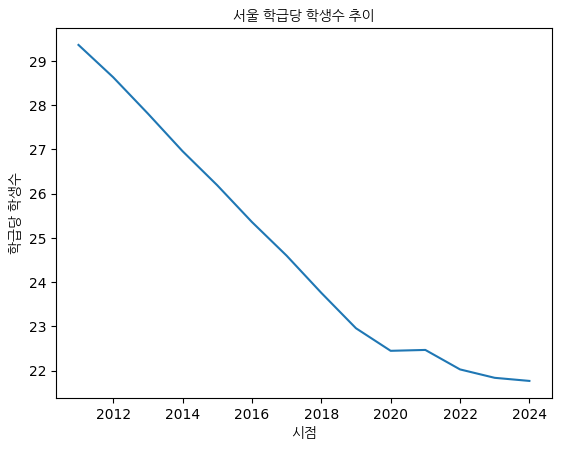

In [99]:
# [코드 11-51] 사용 예시
import matplotlib.pyplot as plt

plt.plot(df['시점'], df['서울특별시'])
plt.xlabel('시점', fontproperties=font10)
plt.ylabel('학급당 학생수', fontproperties=font10)
plt.title('서울 학급당 학생수 추이', fontproperties=font10)
plt.show()

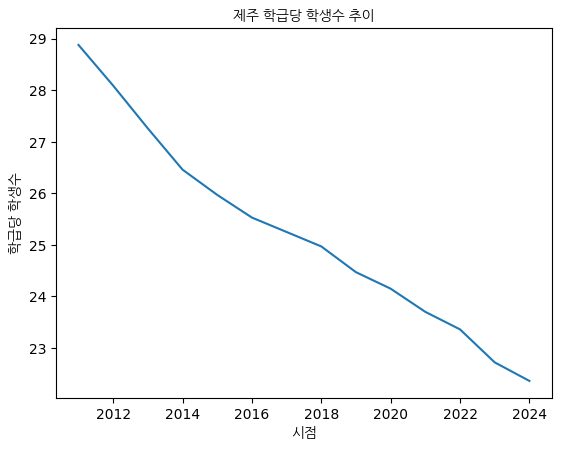

In [100]:
# [코드 11-51] 사용 예시
import matplotlib.pyplot as plt

plt.plot(df['시점'], df['제주특별자치도'])
plt.xlabel('시점', fontproperties=font10)
plt.ylabel('학급당 학생수', fontproperties=font10)
plt.title('제주 학급당 학생수 추이', fontproperties=font10)
plt.show()

In [73]:
# [코드 11-47] 앞/뒤 일부만 보기
df.head()      # 처음 5행
df.head(10)    # 처음 10행
df.tail()      # 마지막 5행

# [코드 11-48] 크기 확인
df.shape       # (행 수, 열 수) 튜플 반환
# 예: (14, 4)는 14행 4열

# 추가 진단 함수 (실무 권장)
df.info()        # 열 이름, 자료형, 누락치 개수 한 번에
df.columns       # 열 이름 목록
df.dtypes        # 각 열의 자료형

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   항목       14 non-null     object 
 1   시점       14 non-null     int64  
 2   서울특별시    14 non-null     float64
 3   제주특별자치도  14 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 580.0+ bytes


,0
항목,object
시점,int64
서울특별시,float64
제주특별자치도,float64


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3186 entries, 0 to 3497
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   업체명           3186 non-null   object 
 1   모델명           3186 non-null   object 
 2   연료            3186 non-null   object 
 3   변속형식          3186 non-null   object 
 4   차량형식          3186 non-null   object 
 5   자동차 종류        3186 non-null   object 
 6   도심주행연비        3185 non-null   float64
 7   고속도로연비        3185 non-null   float64
 8   CO2배출량(g_km)  3186 non-null   float64
 9   1회충전주행거리(km)  95 non-null     float64
 10  배기량           3186 non-null   float64
 11  등급            3186 non-null   object 
 12  출시연도          3186 non-null   int64  
dtypes: float64(5), int64(1), object(7)
memory usage: 348.5+ KB


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('car20240731.csv',encoding='utf-8-sig')
print(df.shape)
df.head()

(3498, 13)


,업체명,모델명,연료,변속형식,차량형식,자동차 종류,도심주행연비,고속도로연비,CO2배출량(g_km),1회충전주행거리(km),배기량,등급,출시연도
0,볼보,볼보 V60CCB5 AWD,휘발유,자동,하이브리드,승용차,8.7,11.9,175.0,NaN,1969.0,4등급,2024
1,볼보,볼보 XC60T8 AWD,전기+휘발유,자동,PHEV,승용차,16.6,17.1,33.0,61.0,1969.0,PHEV,2024
2,벤츠,Mercedes-Benz GLC 220 d 4MATIC,경유,자동,하이브리드,승용차,13.8,15.5,130.0,NaN,1993.0,2등급,2024
3,벤츠,Mercedes-Benz E 450 4MATIC,휘발유,자동,하이브리드,승용차,9.0,13.1,162.0,NaN,2998.0,4등급,2024
4,랜드로버,더 뉴 레인지로버 P550e SWB,전기+휘발유,자동,PHEV,승용차,11.5,13.1,35.0,80.0,2996.0,PHEV,2024


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3498 entries, 0 to 3497
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   업체명           3498 non-null   object 
 1   모델명           3498 non-null   object 
 2   연료            3498 non-null   object 
 3   변속형식          3498 non-null   object 
 4   차량형식          3498 non-null   object 
 5   자동차 종류        3498 non-null   object 
 6   도심주행연비        3497 non-null   float64
 7   고속도로연비        3497 non-null   float64
 8   CO2배출량(g_km)  3186 non-null   float64
 9   1회충전주행거리(km)  403 non-null    float64
 10  배기량           3187 non-null   float64
 11  등급            3498 non-null   object 
 12  출시연도          3498 non-null   int64  
dtypes: float64(5), int64(1), object(7)
memory usage: 355.4+ KB


In [87]:
df.info()
df[['배기량', '고속도로연비', 'CO2배출량(g_km)']].describe()

<class 'pandas.core.frame.DataFrame'>
Index: 3186 entries, 0 to 3497
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   업체명           3186 non-null   object 
 1   모델명           3186 non-null   object 
 2   연료            3186 non-null   object 
 3   변속형식          3186 non-null   object 
 4   차량형식          3186 non-null   object 
 5   자동차 종류        3186 non-null   object 
 6   도심주행연비        3185 non-null   float64
 7   고속도로연비        3185 non-null   float64
 8   CO2배출량(g_km)  3186 non-null   float64
 9   1회충전주행거리(km)  95 non-null     float64
 10  배기량           3186 non-null   float64
 11  등급            3186 non-null   object 
 12  출시연도          3186 non-null   int64  
dtypes: float64(5), int64(1), object(7)
memory usage: 348.5+ KB


,배기량,고속도로연비,CO2배출량(g_km)
count,3186.000000,3185.000000,3186.000000
mean,2558.677966,12.414662,168.908035
std,964.282913,2.839734,48.694492
min,796.000000,5.900000,14.000000
25%,1995.000000,10.300000,137.000000
50%,2199.000000,12.200000,167.000000
75%,2997.000000,14.400000,199.000000
max,6749.000000,28.000000,354.000000


In [86]:
# 원본 행 수 기록
print('전처리 전:', df.shape)

# 배기량이 0인 행 삭제
df = df[df['배기량'] > 0]

print('전처리 후:', df.shape)
df[['배기량', 'CO2배출량(g_km)']].describe()  # 통계량이 변했음을 확인

전처리 전: (3186, 13)
전처리 후: (3186, 13)


,배기량,CO2배출량(g_km)
count,3186.000000,3186.000000
mean,2558.677966,168.908035
std,964.282913,48.694492
min,796.000000,14.000000
25%,1995.000000,137.000000
50%,2199.000000,167.000000
75%,2997.000000,199.000000
max,6749.000000,354.000000


In [88]:
df1 = df[df['연료'] == '휘발유']
df2 = df[df['연료'] == '경유']

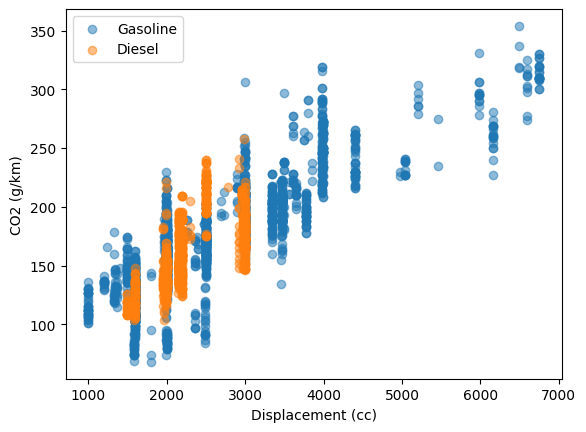

In [90]:
plt.scatter(df1['배기량'], df1['CO2배출량(g_km)'], alpha=0.5, label='Gasoline')
plt.scatter(df2['배기량'], df2['CO2배출량(g_km)'], alpha=0.5, label='Diesel')
plt.xlabel('Displacement (cc)')
plt.ylabel('CO2 (g/km)')
plt.legend()
plt.show()

In [91]:
r1 = df1['배기량'].corr(df1['CO2배출량(g_km)'])
r2 = df2['배기량'].corr(df2['CO2배출량(g_km)'])

print(f'휘발유 차량 상관계수: {r1:.3f}') #0.8~1.0 매우 강함, 0.2 간격으로 낮아지는 5점 척도
print(f'경유  차량 상관계수: {r2:.3f}')

휘발유 차량 상관계수: 0.856
경유  차량 상관계수: 0.656
